# Figures – Vanguard A/B Test
Create presentation figures

**Inputs**
- `../data/clean/df_alldata.csv` – full enriched client table
- `../data/clean/funnel_by_step.csv` – step-level reach counts & rates
- `../data/clean/errors_by_transition.csv` – transition-level error counts & rates
- - `../data/clean/df_times_report.csv` – transition times


## 1  Imports

In [108]:
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import os

## 2 Add CSVs

In [109]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

config

{'data': {'raw': {'file1': '../data/raw/df_final_demo.txt',
   'file2': '../data/raw/df_final_experiment_clients.txt',
   'file3': '../data/raw/df_final_web_data_pt_1.txt',
   'file4': '../data/raw/df_final_web_data_pt_2.txt',
   'file5': '../data/raw/final_web_data_merged.csv'},
  'clean': {'file1': '../data/clean/df_demo_cleaned.csv',
   'file2': '../data/clean/df_experiment_clients_cleaned.csv',
   'file3': '../data/clean/df_test_cids.csv',
   'file4': '../data/clean/df_control_cids.csv',
   'file5': '../data/clean/final_web_data_merged_confirmed.csv',
   'file6': '../data/clean/df_merged_unique_vids.csv',
   'file7': '../data/clean/df_alldata.csv',
   'file8': '../data/clean/errors_by_transition.csv',
   'file9': '../data/clean/funnel_by_step.csv',
   'file10': '../data/clean/df_times_report.csv'}}}

In [110]:
df_c = pd.read_csv(config['data']['clean']['file7'], quotechar='"')
df_e = pd.read_csv(config['data']['clean']['file8'], quotechar='"')
df_f = pd.read_csv(config['data']['clean']['file9'], quotechar='"')
df_t = pd.read_csv(config['data']['clean']['file10'], quotechar='"')

In [111]:
df_t

,step,time(seconds),condition
0,time_start_step1,38.72,control
1,time_start_step1,25.58,test
2,time_step1_step2,33.30,control
3,time_step1_step2,35.59,test
4,time_step2_step3,85.48,control
5,time_step2_step3,79.81,test
6,time_step3_confirm,127.74,control
7,time_step3_confirm,102.68,test


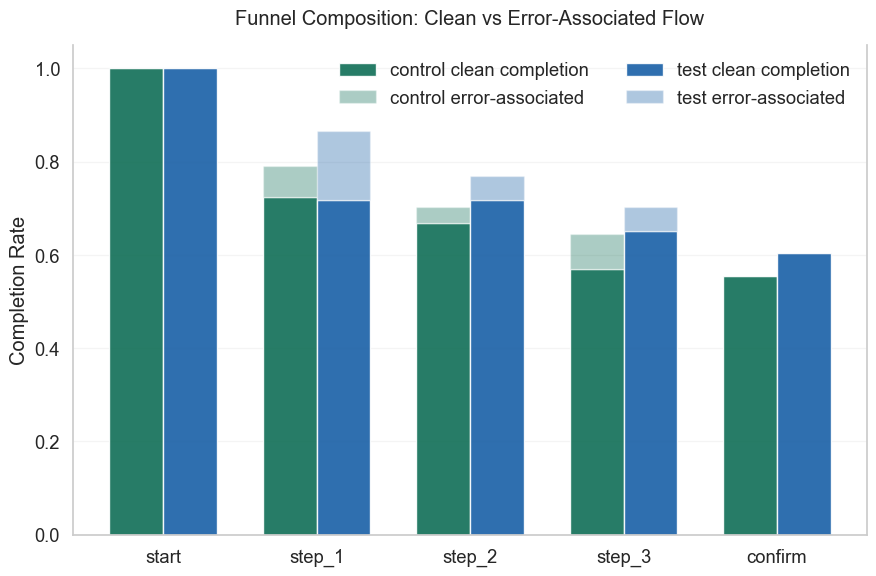

In [71]:
sns.set_theme(style="whitegrid", font_scale=1.2)

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

# -----------------------------
# completion
# -----------------------------
df_f_plot = df_f.copy()
df_f_plot["step"] = pd.Categorical(df_f_plot["step"], categories=step_order, ordered=True)

completion = (
    df_f_plot.groupby(["step", "group"])["completion_rate"]
    .mean()
    .unstack()
    .reindex(step_order)
)

# -----------------------------
# shifted error
# -----------------------------
transition_to_step = {
    "start→step_1": "step_1",
    "step_1→step_2": "step_2",
    "step_2→step_3": "step_3",
    "step_3→confirm": "confirm"
}

df_e_plot = df_e.copy()
df_e_plot["step"] = df_e_plot["transition"].map(transition_to_step)

error_shifted = (
    df_e_plot.groupby(["step", "group"])["error_rate"]
    .mean()
    .unstack()
    .reindex(step_order)
    .fillna(0)
)

# -----------------------------
# FIX: start baseline
# -----------------------------
for group in ["control", "test"]:
    completion.loc["start", group] = 1.0
    error_shifted.loc["start", group] = 0.0

# -----------------------------
# clean component
# -----------------------------
clean = completion - error_shifted
clean = clean.clip(lower=0)

# -----------------------------
# plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(step_order))
width = 0.35

colors = {
    "control": "#0f6e56",
    "test": "#185fa6"
}

for i, group in enumerate(["control", "test"]):

    ax.bar(
        x + i*width - width/2,
        clean[group],
        width,
        color=colors[group],
        alpha=0.9,
        label=f"{group} clean completion"
    )

    ax.bar(
        x + i*width - width/2,
        error_shifted[group],
        width,
        bottom=clean[group],
        color=colors[group],
        alpha=0.35,
        label=f"{group} error-associated"
    )

# -----------------------------
# styling
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(step_order)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Completion Rate")
ax.set_title("Funnel Composition: Clean vs Error-Associated Flow", pad=15)

ax.grid(True, axis="y", alpha=0.2)
ax.grid(False, axis="x")

for spine in ["top", "right"]:
    ax.spines["top"].set_visible(False)

ax.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

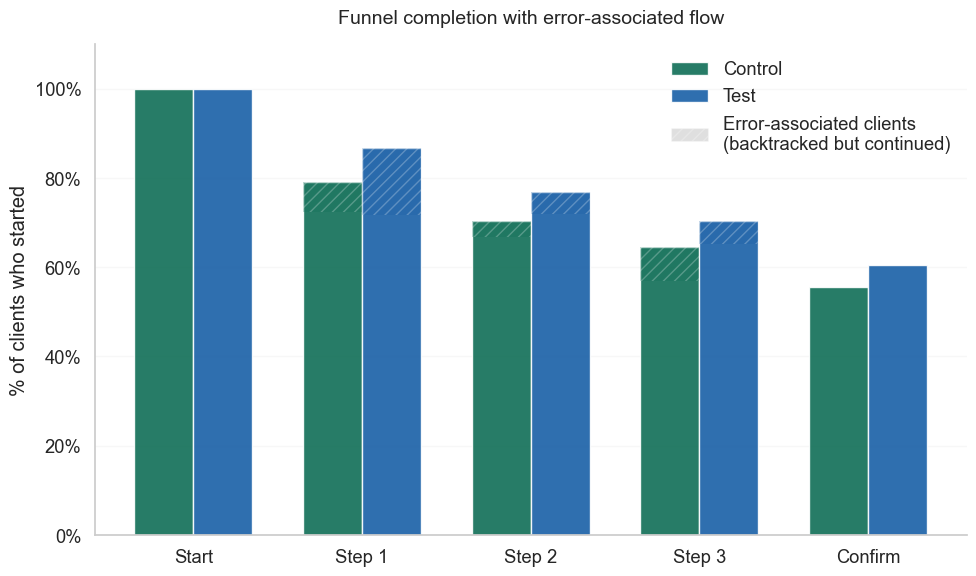

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(step_order))
width = 0.35

colors = {"control": "#0f6e56", "test": "#185fa6"}

for i, group in enumerate(["control", "test"]):
    offset = x + i*width - width/2
    
    # full completion bar
    ax.bar(offset, completion[group], width,
           color=colors[group], alpha=0.9, zorder=2)
    
    # error rate as hatched overlay — same bar, different texture
    ax.bar(offset, error_shifted[group], width,
           bottom=completion[group] - error_shifted[group],
           color=colors[group], alpha=0.25, hatch='///', zorder=3,
           linewidth=0)

# manual legend — keep it simple
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#0f6e56', alpha=0.9, label='Control'),
    Patch(facecolor='#185fa6', alpha=0.9, label='Test'),
    Patch(facecolor='grey', alpha=0.25, hatch='///', label='Error-associated clients\n(backtracked but continued)'),
]
ax.legend(handles=legend_elements, frameon=False, loc='upper right')

ax.set_xticks(x)
ax.set_xticklabels(['Start', 'Step 1', 'Step 2', 'Step 3', 'Confirm'])
ax.set_ylim(0, 1.1)
ax.set_ylabel("% of clients who started")
ax.set_title("Funnel completion with error-associated flow", pad=15, fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, axis='y', alpha=0.15)
ax.grid(False, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

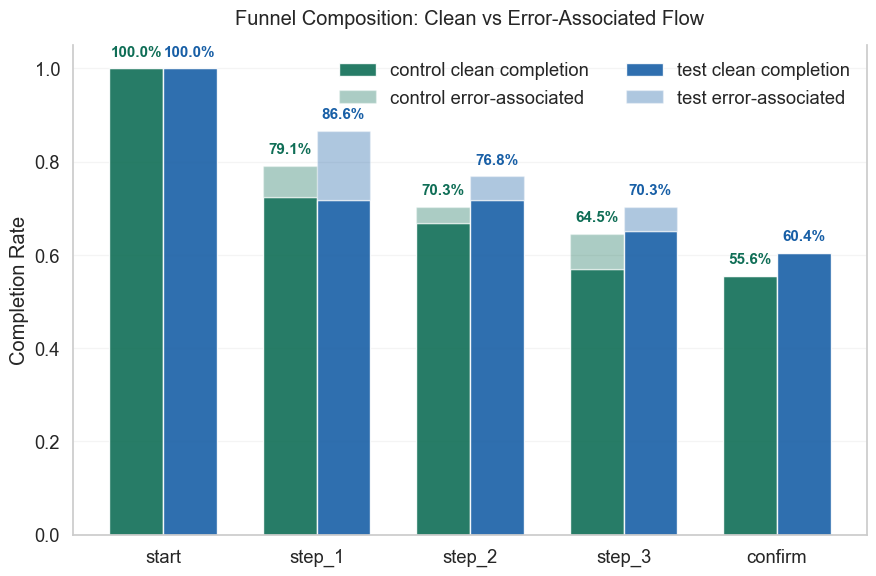

In [73]:
sns.set_theme(style="whitegrid", font_scale=1.2)

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

# -----------------------------
# completion
# -----------------------------
df_f_plot = df_f.copy()
df_f_plot["step"] = pd.Categorical(df_f_plot["step"], categories=step_order, ordered=True)

completion = (
    df_f_plot.groupby(["step", "group"])["completion_rate"]
    .mean()
    .unstack()
    .reindex(step_order)
)

# -----------------------------
# shifted error
# -----------------------------
transition_to_step = {
    "start→step_1": "step_1",
    "step_1→step_2": "step_2",
    "step_2→step_3": "step_3",
    "step_3→confirm": "confirm"
}

df_e_plot = df_e.copy()
df_e_plot["step"] = df_e_plot["transition"].map(transition_to_step)

error_shifted = (
    df_e_plot.groupby(["step", "group"])["error_rate"]
    .mean()
    .unstack()
    .reindex(step_order)
    .fillna(0)
)

# -----------------------------
# FIX: start baseline
# -----------------------------
for group in ["control", "test"]:
    completion.loc["start", group] = 1.0
    error_shifted.loc["start", group] = 0.0

# -----------------------------
# clean component
# -----------------------------
clean = completion - error_shifted
clean = clean.clip(lower=0)

# -----------------------------
# plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(step_order))
width = 0.35

colors = {
    "control": "#0f6e56",
    "test": "#185fa6"
}

for i, group in enumerate(["control", "test"]):

    ax.bar(
        x + i*width - width/2,
        clean[group],
        width,
        color=colors[group],
        alpha=0.9,
        label=f"{group} clean completion"
    )

    ax.bar(
        x + i*width - width/2,
        error_shifted[group],
        width,
        bottom=clean[group],
        color=colors[group],
        alpha=0.35,
        label=f"{group} error-associated"
    )

# -----------------------------
# styling
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(step_order)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Completion Rate")
ax.set_title("Funnel Composition: Clean vs Error-Associated Flow", pad=15)

ax.grid(True, axis="y", alpha=0.2)
ax.grid(False, axis="x")

for spine in ["top", "right"]:
    ax.spines["top"].set_visible(False)

ax.legend(frameon=False, ncol=2)

# -----------------------------
# add total completion labels on top
# -----------------------------
for i, group in enumerate(["control", "test"]):

    total = clean[group] + error_shifted[group]

    for j, step in enumerate(step_order):

        x_pos = j + i * width - width / 2
        y_pos = total.loc[step]

        ax.text(
            x_pos,
            y_pos + 0.02,  # small offset above bar
            f"{y_pos:.1%}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color=colors[group]
        )
plt.tight_layout()
plt.show()

In [74]:
df_e

,transition,group,error_count,error_rate
0,start→step_1,control,1204,0.0664
1,start→step_1,test,3273,0.1488
2,step_1→step_2,control,653,0.0360
3,step_1→step_2,test,1095,0.0498
4,step_2→step_3,control,1370,0.0755
5,step_2→step_3,test,1137,0.0517
6,step_3→confirm,control,0,0.0000
7,step_3→confirm,test,1,0.0000


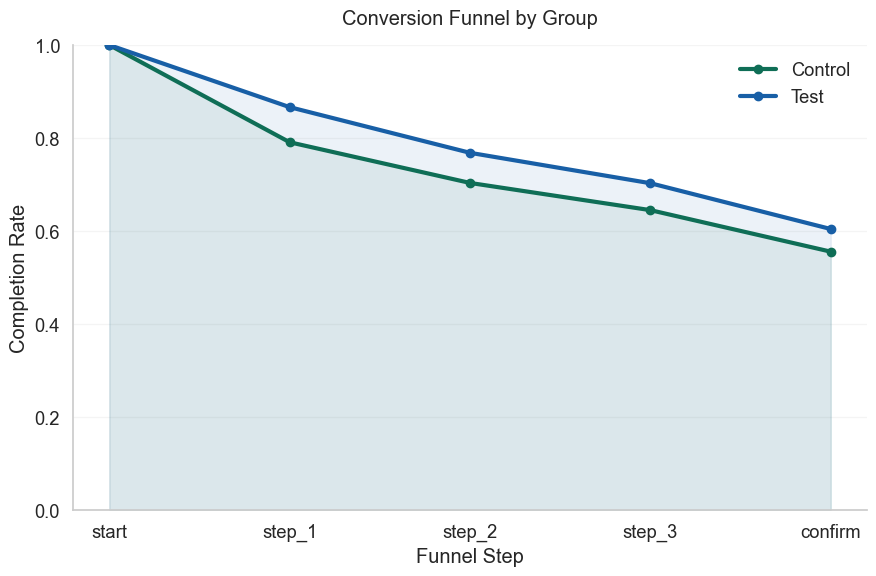

In [75]:
sns.set_theme(style="whitegrid", font_scale=1.2)

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

df_plot = df_f.copy()
df_plot["step"] = pd.Categorical(df_plot["step"], categories=step_order, ordered=True)

palette = {
    "control": "#0f6e56",  # green
    "test": "#185fa6"      # blue
}

fig, ax = plt.subplots(figsize=(9, 6))

# --- funnel lines ---
for group in ["control", "test"]:
    d = df_plot[df_plot["group"] == group].sort_values("step")

    ax.plot(
        d["step"],
        d["completion_rate"],
        marker="o",
        linewidth=3,
        color=palette[group],
        label=group.capitalize()
    )

    # subtle area fill (adds “funnel feel” without clutter)
    ax.fill_between(
        d["step"].cat.codes,
        d["completion_rate"],
        alpha=0.08,
        color=palette[group]
    )

# --- axis + styling ---
ax.set_title("Conversion Funnel by Group", pad=15)
ax.set_xlabel("Funnel Step")
ax.set_ylabel("Completion Rate")
ax.set_ylim(0, 1)

ax.grid(True, axis="y", alpha=0.2)
ax.grid(False, axis="x")

# clean spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
    ax.spines[spine].set_color("#cbd5e1")

# legend
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_4104\2480459023.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(step_labels)


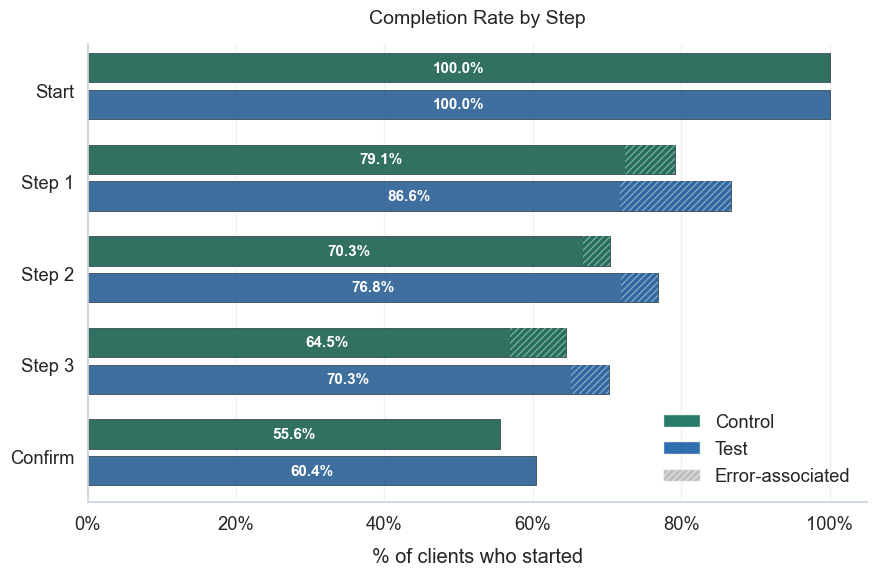

In [76]:


sns.set_theme(style="whitegrid", font_scale=1.2)

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
step_labels = ["Start", "Step 1", "Step 2", "Step 3", "Confirm"]

palette = {"control": "#0f6e56", "test": "#185fa6"}

# merge completion and error into one df
df_plot = df_f.copy()
df_plot["step"] = pd.Categorical(df_plot["step"], categories=step_order, ordered=True)

# map errors to steps
transition_to_step = {
    "start→step_1": "step_1",
    "step_1→step_2": "step_2",
    "step_2→step_3": "step_3",
    "step_3→confirm": "confirm"
}
df_e_plot = df_e.copy()
df_e_plot["step"] = df_e_plot["transition"].map(transition_to_step)
error_lookup = df_e_plot.groupby(["step", "group"])["error_rate"].mean().to_dict()

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=df_plot,
    y="step",
    x="completion_rate",
    hue="group",
    palette=palette,
    ax=ax,
    edgecolor="#2f3e46",
    linewidth=0.6,
    alpha=0.9,
    dodge=True,
    order=step_order
)

# shrink bar height
bar_height = 0.32
all_bars = []
for container in ax.containers:
    for bar in container:
        bar.set_height(bar_height)
        all_bars.append(bar)

# overlay error hatching — stronger and visible
for container_idx, (container, group) in enumerate(zip(ax.containers, ["control", "test"])):
    for bar, step in zip(container, step_order):
        err = error_lookup.get((step, group), 0)
        if err > 0:
            comp = bar.get_width()
            y = bar.get_y()
            # draw hatch patch over the error portion of the bar
            hatch_patch = mpatches.FancyArrowPatch
            rect = plt.Rectangle(
                (comp - err, y),
                err, bar_height,
                linewidth=0,
                edgecolor='white',
                facecolor=palette[group],
                alpha=0.4,
                hatch='/////',
                zorder=4
            )
            ax.add_patch(rect)

# labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_width():.1%}" for v in container],
        label_type="center",
        fontsize=11,
        color="white",
        fontweight="bold"
    )
# for container in ax.containers:
#     for bar in container:
#         width = bar.get_width()
#         y_center = bar.get_y() + bar.get_height() / 2
#         ax.text(
#             0.24,  # fixed x position for all labels
#             y_center,
#             f"{width:.1%}",
#             va="center", ha="left",
#             fontsize=11, color="white", fontweight="bold"
#         )
    # fix label alignment + percentage x axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))



# styling
ax.set_xlim(0, 1.05)
ax.set_xlabel("% of clients who started", labelpad=10)
ax.set_ylabel("")
ax.set_yticklabels(step_labels)
ax.set_title("Completion Rate by Step", pad=15, fontsize=14)
ax.grid(True, axis="x", color="#94a3b8", linestyle="-", alpha=0.15)
ax.grid(False, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cbd5e1")
ax.spines["bottom"].set_color("#cbd5e1")

# legend
legend_elements = [
    mpatches.Patch(facecolor="#0f6e56", alpha=0.9, label="Control"),
    mpatches.Patch(facecolor="#185fa6", alpha=0.9, label="Test"),
    mpatches.Patch(facecolor="grey", alpha=0.5, hatch='/////', label="Error-associated"),
]
ax.legend(handles=legend_elements, frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

In [77]:
df_f

,step,group,clients_reached,completion_rate
0,start,control,22934,1.0000
1,start,test,25388,1.0000
2,step_1,control,18139,0.7909
3,step_1,test,21997,0.8664
4,step_2,control,16132,0.7034
5,step_2,test,19503,0.7682
6,step_3,control,14790,0.6449
7,step_3,test,17842,0.7028
8,confirm,control,12743,0.5556
9,confirm,test,15343,0.6043


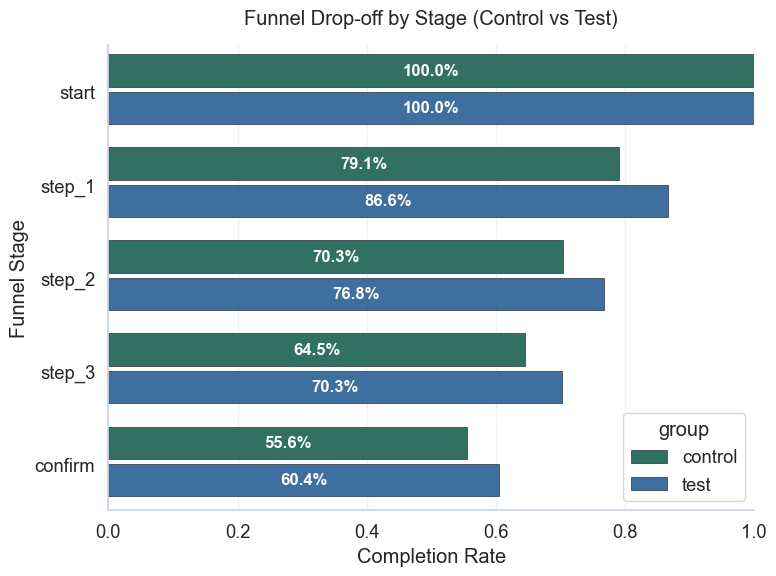

In [78]:
sns.set_theme(style="whitegrid", font_scale=1.2)

df_plot = df_f.copy()

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
df_plot["step"] = pd.Categorical(df_plot["step"], categories=step_order, ordered=True)

palette = {
    "control": "#0f6e56",
    "test": "#185fa6"
}

fig, ax = plt.subplots(figsize=(8, 6))

# --- IMPORTANT: adjust width via seaborn + dodge separation ---
sns.barplot(
    data=df_plot,
    y="step",
    x="completion_rate",
    hue="group",
    palette=palette,
    ax=ax,
    edgecolor="#2f3e46",
    linewidth=0.6,
    alpha=0.9,
    dodge=True
)

# --- manually shrink bar width for more spacing within steps ---
for container in ax.containers:
    for bar in container:
        bar.set_height(0.35)   # controls vertical thickness (key fix)

# --- Grid styling ---
ax.grid(True, axis="x", color="#94a3b8", linestyle="-", alpha=0.15)
ax.grid(False, axis="y")

ax.set_xlim(0, 1)
ax.set_xlabel("Completion Rate")
ax.set_ylabel("Funnel Stage")

# --- Spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cbd5e1")

ax.set_title("Funnel Drop-off by Stage (Control vs Test)", pad=15)

# --- Labels ---
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_width():.1%}" for v in container],
        label_type="center",
        fontsize=12,
        color="white",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [79]:
df_f[df_f.step=='confirm']

,step,group,clients_reached,completion_rate
8,confirm,control,12743,0.5556
9,confirm,test,15343,0.6043


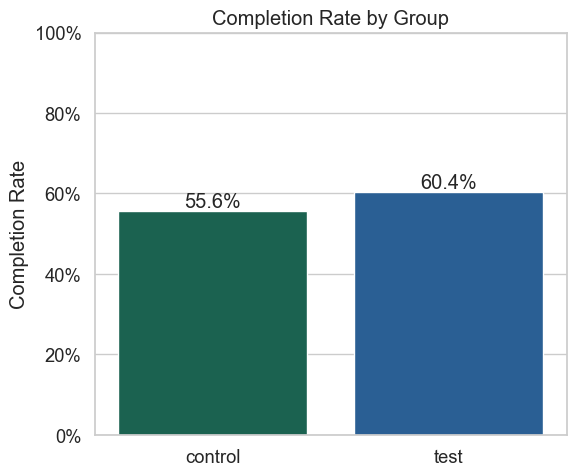

In [80]:
sns.set_theme(style="whitegrid", font_scale=1.2)

df_plot = df_f.copy()
df_plot = df_plot[df_plot.step=='confirm']
df_plot["completion_rate"] = df_plot["completion_rate"].astype(float)

order = ["control", "test"]

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=df_plot,
    x="group",
    y="completion_rate",
    order=order,
    palette=["#0f6e56", "#185fa6"],
    hue='group'
)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Completion Rate by Group")
ax.set_xlabel("")
ax.set_ylabel("Completion Rate")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_4104\2983291051.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


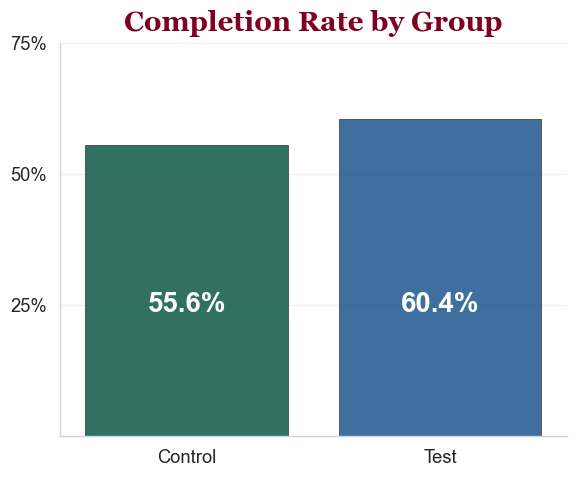

In [107]:
sns.set_theme(style="whitegrid", font_scale=1.2)

df_plot = df_f.copy()
df_plot = df_plot[df_plot.step == "confirm"]
df_plot["completion_rate"] = df_plot["completion_rate"].astype(float)

order = ["control", "test"]

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data=df_plot,
    x="group",
    y="completion_rate",
    order=order,
    palette=["#0f6e56", "#185fa6"],
    ax=ax,
    edgecolor="#2f3e46",
    linewidth=0.6,
    alpha=0.9
)

# --- Grid styling ---
ax.grid(True, axis="y", color="#94a3b8", linestyle="-", alpha=0.15)
ax.grid(False, axis="x")

# --- Y axis: cap at 75% ---
ax.set_ylim(0, 0.75)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_yticks([0.25, 0.50, 0.75])

# ax.set_title("Completion Rate by Group", pad=15)
gfont = {'fontname':'Georgia'}
ax.set_title("Completion Rate by Group", fontsize=20, y=1.01, color='#800020',fontweight='bold',**gfont)
plt.tight_layout()


ax.set_xlabel("")
# ax.set_ylabel("Completion Rate")
ax.set(ylabel=None)

# --- Spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cbd5e1")
    ax.spines[spine].set_linewidth(1)

# --- Labels fixed at y = 25% ---
label_y = 0.25

for p, color in zip(ax.patches, ["#0f6e56", "#185fa6"]):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        label_y,
        f"{height:.1%}",
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold",
        color="white"
    )
ax.set_xticks(range(len(order)))
ax.set_xticklabels(["Control", "Test"])
plt.tight_layout()
output_path = os.path.join("..", "figures", "completion_groups.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_4104\568375131.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(step_labels)
C:\Users\clair\AppData\Local\Temp\ipykernel_4104\568375131.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(step_labels)


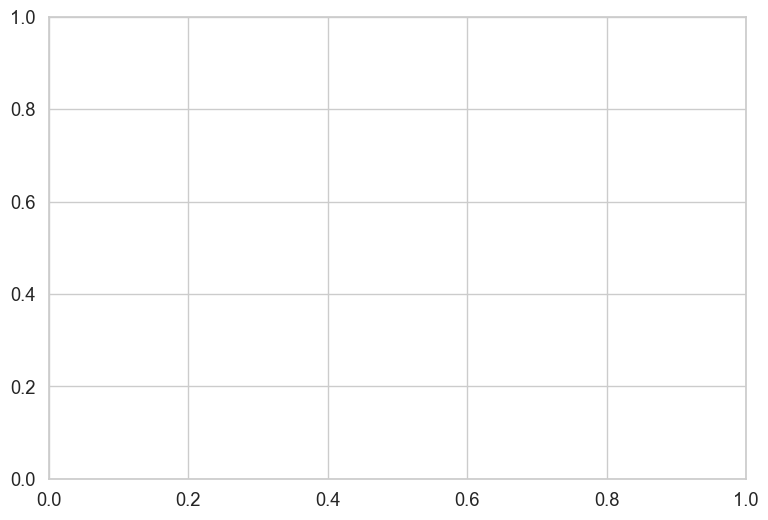

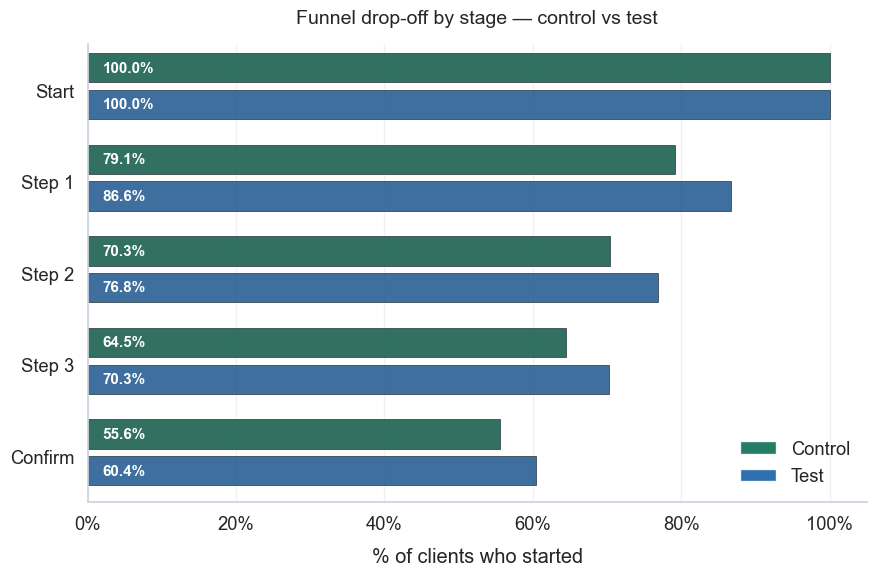

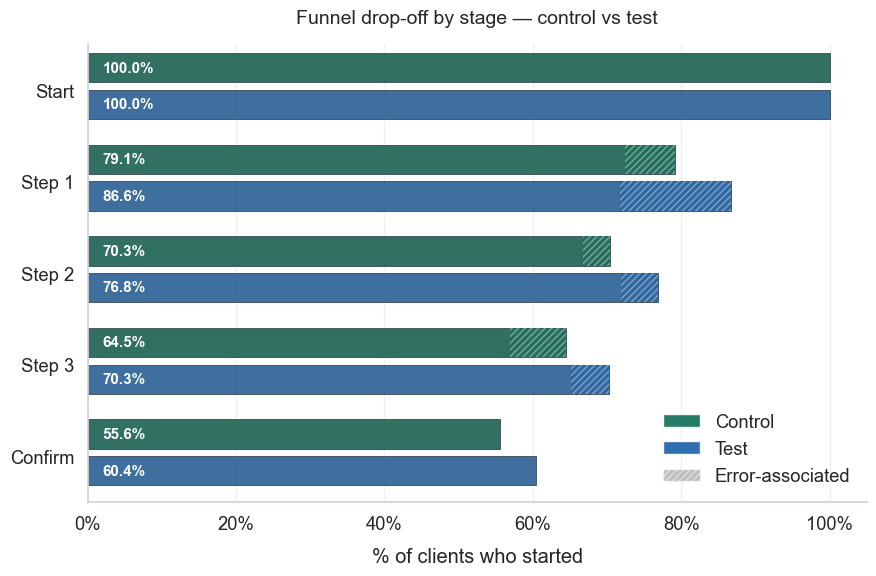

In [98]:
sns.set_theme(style="whitegrid", font_scale=1.2)

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
step_labels = ["Start", "Step 1", "Step 2", "Step 3", "Confirm"]

palette = {"control": "#0f6e56", "test": "#185fa6"}

# merge completion and error into one df
df_plot = df_f.copy()
df_plot["step"] = pd.Categorical(df_plot["step"], categories=step_order, ordered=True)

# map errors to steps
transition_to_step = {
    "start→step_1": "step_1",
    "step_1→step_2": "step_2",
    "step_2→step_3": "step_3",
    "step_3→confirm": "confirm"
}
df_e_plot = df_e.copy()
df_e_plot["step"] = df_e_plot["transition"].map(transition_to_step)
error_lookup = df_e_plot.groupby(["step", "group"])["error_rate"].mean().to_dict()

fig, ax = plt.subplots(figsize=(9, 6))


def plot_funnel(ax, show_errors=False):
    sns.barplot(
        data=df_plot,
        y="step",
        x="completion_rate",
        hue="group",
        palette=palette,
        ax=ax,
        edgecolor="#2f3e46",
        linewidth=0.6,
        alpha=0.9,
        dodge=True,
        order=step_order
    )

    for container in ax.containers:
        for bar in container:
            bar.set_height(bar_height)

    if show_errors:
        for container, group in zip(ax.containers, ["control", "test"]):
            for bar, step in zip(container, step_order):
                err = error_lookup.get((step, group), 0)
                if err > 0:
                    comp = bar.get_width()
                    y = bar.get_y()
                    rect = plt.Rectangle(
                        (comp - err, y), err, bar_height,
                        linewidth=0, edgecolor='white',
                        facecolor=palette[group],
                        alpha=0.4, hatch='/////', zorder=4
                    )
                    ax.add_patch(rect)

    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            y_center = bar.get_y() + bar.get_height() / 2
            ax.text(0.02, y_center, f"{width:.1%}",
                    va="center", ha="left",
                    fontsize=11, color="white", fontweight="bold")

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("% of clients who started", labelpad=10)
    ax.set_ylabel("")
    ax.set_yticklabels(step_labels)
    ax.grid(True, axis="x", color="#94a3b8", linestyle="-", alpha=0.15)
    ax.grid(False, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cbd5e1")
    ax.spines["bottom"].set_color("#cbd5e1")

    legend_elements = [
        mpatches.Patch(facecolor="#0f6e56", alpha=0.9, label="Control"),
        mpatches.Patch(facecolor="#185fa6", alpha=0.9, label="Test"),
    ]
    if show_errors:
        legend_elements.append(
            mpatches.Patch(facecolor="grey", alpha=0.5, hatch='/////', label="Error-associated")
        )
    ax.legend(handles=legend_elements, frameon=False, loc="lower right")

# plot 1 — clean
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("Funnel drop-off by stage — control vs test", pad=15, fontsize=14)
plot_funnel(ax, show_errors=False)
plt.tight_layout()
plt.savefig('../figures/funnel_clean.png', dpi=150)

# plot 2 — with errors
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("Funnel drop-off by stage — control vs test", pad=15, fontsize=14)
plot_funnel(ax, show_errors=True)
plt.tight_layout()
plt.savefig('../figures/funnel_errors.png', dpi=150)

C:\Users\clair\AppData\Local\Temp\ipykernel_4104\2374723005.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(step_labels)
C:\Users\clair\AppData\Local\Temp\ipykernel_4104\2374723005.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(step_labels)


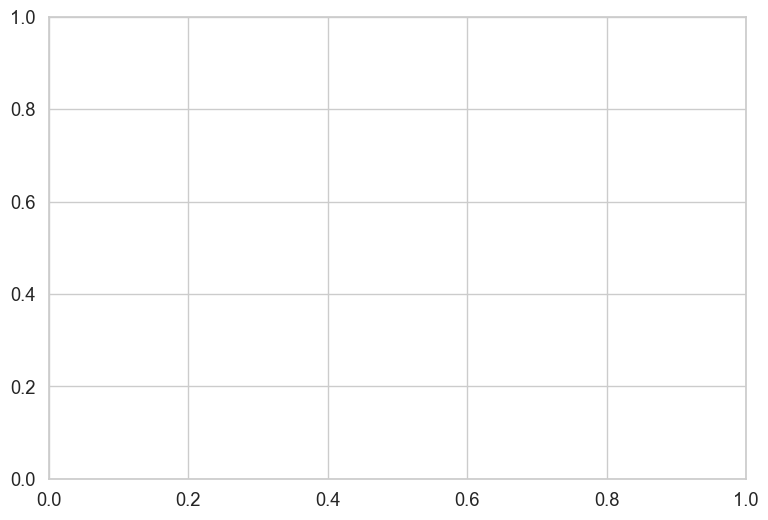

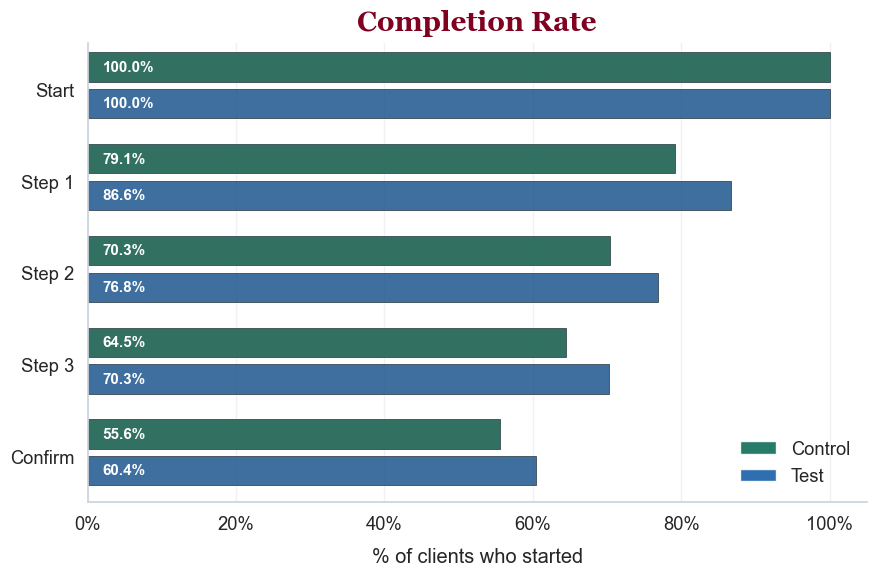

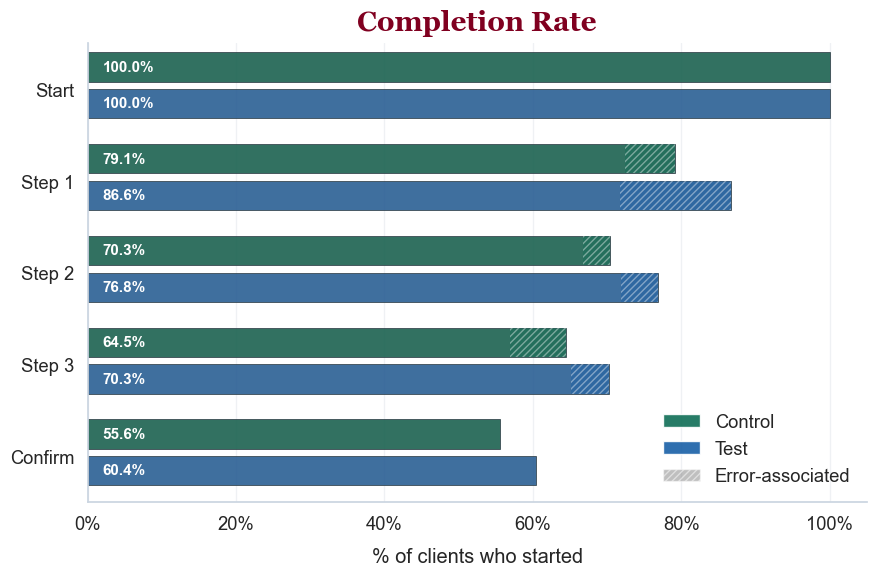

In [99]:
sns.set_theme(style="whitegrid", font_scale=1.2)

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
step_labels = ["Start", "Step 1", "Step 2", "Step 3", "Confirm"]

palette = {"control": "#0f6e56", "test": "#185fa6"}

# merge completion and error into one df
df_plot = df_f.copy()
df_plot["step"] = pd.Categorical(df_plot["step"], categories=step_order, ordered=True)

# map errors to steps
transition_to_step = {
    "start→step_1": "step_1",
    "step_1→step_2": "step_2",
    "step_2→step_3": "step_3",
    "step_3→confirm": "confirm"
}
df_e_plot = df_e.copy()
df_e_plot["step"] = df_e_plot["transition"].map(transition_to_step)
error_lookup = df_e_plot.groupby(["step", "group"])["error_rate"].mean().to_dict()

fig, ax = plt.subplots(figsize=(9, 6))


def plot_funnel(ax, show_errors=False):
    sns.barplot(
        data=df_plot,
        y="step",
        x="completion_rate",
        hue="group",
        palette=palette,
        ax=ax,
        edgecolor="#2f3e46",
        linewidth=0.6,
        alpha=0.9,
        dodge=True,
        order=step_order
    )

    for container in ax.containers:
        for bar in container:
            bar.set_height(bar_height)

    if show_errors:
        for container, group in zip(ax.containers, ["control", "test"]):
            for bar, step in zip(container, step_order):
                err = error_lookup.get((step, group), 0)
                if err > 0:
                    comp = bar.get_width()
                    y = bar.get_y()
                    rect = plt.Rectangle(
                        (comp - err, y), err, bar_height,
                        linewidth=0, edgecolor='white',
                        facecolor=palette[group],
                        alpha=0.4, hatch='/////', zorder=4
                    )
                    ax.add_patch(rect)

    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            y_center = bar.get_y() + bar.get_height() / 2
            ax.text(0.02, y_center, f"{width:.1%}",
                    va="center", ha="left",
                    fontsize=11, color="white", fontweight="bold")

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("% of clients who started", labelpad=10)
    ax.set_ylabel("")
    ax.set_yticklabels(step_labels)
    ax.grid(True, axis="x", color="#94a3b8", linestyle="-", alpha=0.15)
    ax.grid(False, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cbd5e1")
    ax.spines["bottom"].set_color("#cbd5e1")

    legend_elements = [
        mpatches.Patch(facecolor="#0f6e56", alpha=0.9, label="Control"),
        mpatches.Patch(facecolor="#185fa6", alpha=0.9, label="Test"),
    ]
    if show_errors:
        legend_elements.append(
            mpatches.Patch(facecolor="grey", alpha=0.5, hatch='/////', label="Error-associated")
        )
    ax.legend(handles=legend_elements, frameon=False, loc="lower right")

# plot 1 — clean
fig, ax = plt.subplots(figsize=(9, 6))
# ax.set_title("Funnel drop-off by stage — control vs test", pad=15, fontsize=14)
plot_funnel(ax, show_errors=False)

gfont = {'fontname':'Georgia'}
ax.set_title("Completion Rate", fontsize=20, y=1.01, color='#800020',fontweight='bold',**gfont)
plt.tight_layout()
output_path = os.path.join("..", "figures", "funnel_clean.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)


# plt.savefig('../figures/funnel_clean.png', dpi=150)

# plot 2 — with errors
fig, ax = plt.subplots(figsize=(9, 6))
# ax.set_title("Funnel drop-off by stage — control vs test", pad=15, fontsize=14)
plot_funnel(ax, show_errors=True)

gfont = {'fontname':'Georgia'}
ax.set_title("Completion Rate", fontsize=20, y=1.01, color='#800020',fontweight='bold',**gfont)
plt.tight_layout()
output_path = os.path.join("..", "figures", "funnel_errors.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)

# plt.savefig('../figures/funnel_errors.png', dpi=150)

C:\Users\clair\AppData\Local\Temp\ipykernel_4104\3102631055.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(step_labels)
C:\Users\clair\AppData\Local\Temp\ipykernel_4104\3102631055.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(step_labels)


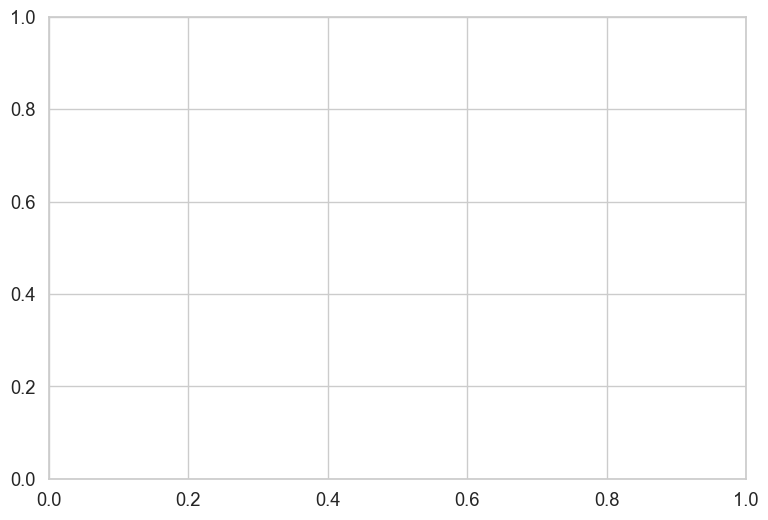

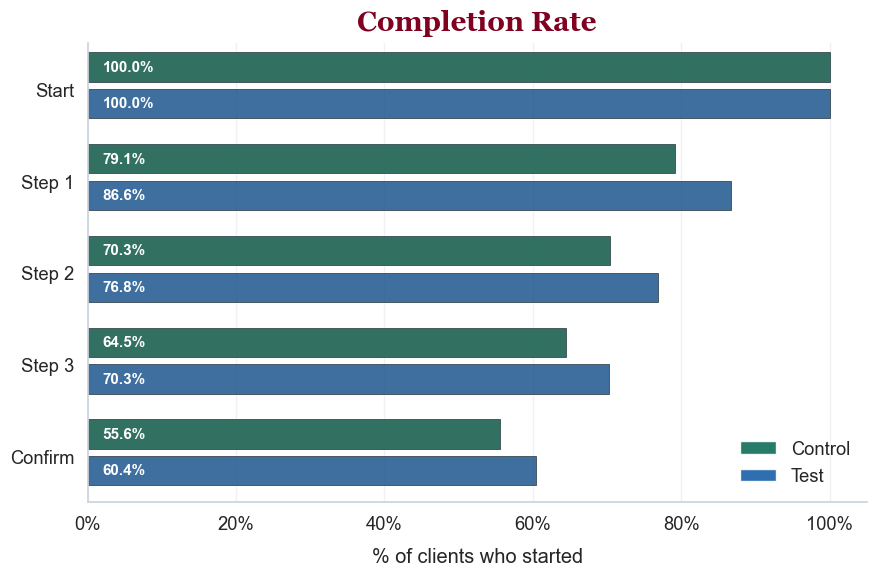

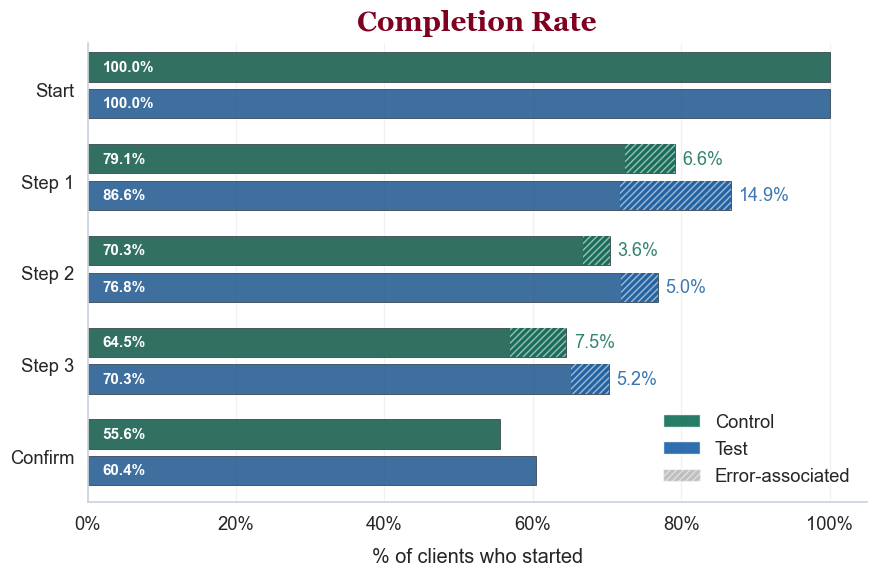

In [105]:
sns.set_theme(style="whitegrid", font_scale=1.2)

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
step_labels = ["Start", "Step 1", "Step 2", "Step 3", "Confirm"]

palette = {"control": "#0f6e56", "test": "#185fa6"}

# merge completion and error into one df
df_plot = df_f.copy()
df_plot["step"] = pd.Categorical(df_plot["step"], categories=step_order, ordered=True)

# map errors to steps
transition_to_step = {
    "start→step_1": "step_1",
    "step_1→step_2": "step_2",
    "step_2→step_3": "step_3",
    "step_3→confirm": "confirm"
}
df_e_plot = df_e.copy()
df_e_plot["step"] = df_e_plot["transition"].map(transition_to_step)
error_lookup = df_e_plot.groupby(["step", "group"])["error_rate"].mean().to_dict()

fig, ax = plt.subplots(figsize=(9, 6))


def plot_funnel(ax, show_errors=False):
    sns.barplot(
        data=df_plot,
        y="step",
        x="completion_rate",
        hue="group",
        palette=palette,
        ax=ax,
        edgecolor="#2f3e46",
        linewidth=0.6,
        alpha=0.9,
        dodge=True,
        order=step_order
    )

    for container in ax.containers:
        for bar in container:
            bar.set_height(bar_height)

    if show_errors:
        for container, group in zip(ax.containers, ["control", "test"]):
            for bar, step in zip(container, step_order):
                err = error_lookup.get((step, group), 0)
                if err > 0:
                    comp = bar.get_width()
                    y = bar.get_y()
                    rect = plt.Rectangle(
                        (comp - err, y), err, bar_height,
                        linewidth=0, edgecolor='white',
                        facecolor=palette[group],
                        alpha=0.4, hatch='/////', zorder=4
                    )
                    ax.add_patch(rect)

    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            y_center = bar.get_y() + bar.get_height() / 2
            ax.text(0.02, y_center, f"{width:.1%}",
                    va="center", ha="left",
                    fontsize=11, color="white", fontweight="bold")

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("% of clients who started", labelpad=10)
    ax.set_ylabel("")
    ax.set_yticklabels(step_labels)
    ax.grid(True, axis="x", color="#94a3b8", linestyle="-", alpha=0.15)
    ax.grid(False, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cbd5e1")
    ax.spines["bottom"].set_color("#cbd5e1")

    legend_elements = [
        mpatches.Patch(facecolor="#0f6e56", alpha=0.9, label="Control"),
        mpatches.Patch(facecolor="#185fa6", alpha=0.9, label="Test"),
    ]
    # if show_errors:
    if show_errors:
        for container, group in zip(ax.containers, ["control", "test"]):
            for bar, step in zip(container, step_order):
                err = error_lookup.get((step, group), 0)
                if err > 0:
                    comp = bar.get_width()
                    y = bar.get_y()
                    rect = plt.Rectangle(
                        (comp - err, y), err, bar_height,
                        linewidth=0, edgecolor='white',
                        facecolor=palette[group],
                        alpha=0.4, hatch='/////', zorder=4
                    )
                    ax.add_patch(rect)
                    # error rate label to the right of bar
                    y_center = y + bar_height / 2
                    ax.text(comp + 0.01, y_center,
                            f"{err:.1%}",
                            va="center", ha="left",
                            fontsize=13, color=palette[group],
                            alpha=0.85)
        legend_elements.append(
            mpatches.Patch(facecolor="grey", alpha=0.5, hatch='/////', label="Error-associated")
        )
    ax.legend(handles=legend_elements, frameon=False, loc="lower right")

# plot 1 — clean
fig, ax = plt.subplots(figsize=(9, 6))
# ax.set_title("Funnel drop-off by stage — control vs test", pad=15, fontsize=14)
plot_funnel(ax, show_errors=False)

gfont = {'fontname':'Georgia'}
ax.set_title("Completion Rate", fontsize=20, y=1.01, color='#800020',fontweight='bold',**gfont)
plt.tight_layout()
output_path = os.path.join("..", "figures", "funnel_clean.png")
# plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)


# plt.savefig('../figures/funnel_clean.png', dpi=150)

# plot 2 — with errors
fig, ax = plt.subplots(figsize=(9, 6))
# ax.set_title("Funnel drop-off by stage — control vs test", pad=15, fontsize=14)
plot_funnel(ax, show_errors=True)

gfont = {'fontname':'Georgia'}
ax.set_title("Completion Rate", fontsize=20, y=1.01, color='#800020',fontweight='bold',**gfont)
plt.tight_layout()
output_path = os.path.join("..", "figures", "funnel_errors.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)

# plt.savefig('../figures/funnel_errors.png', dpi=150)

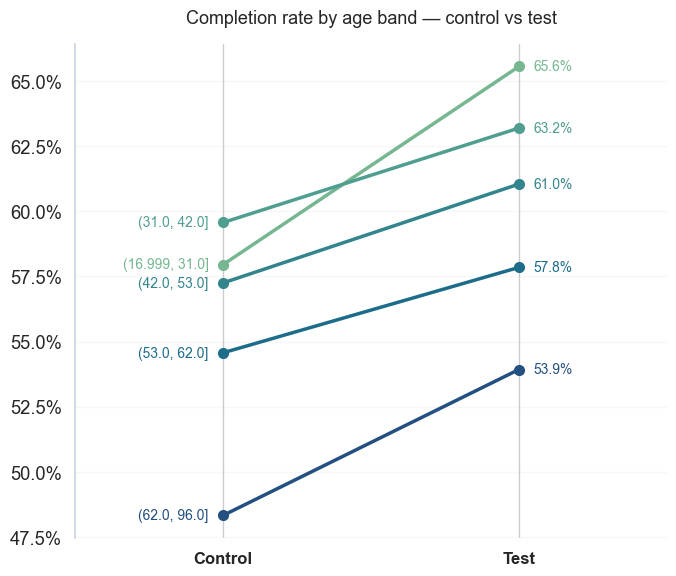

In [83]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd

df_plot = df_c.copy()
df_plot['age_band'] = pd.qcut(df_plot['clnt_age'], q=5)

slope_data = df_plot.groupby(['age_band', 'group'])['completed'].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 6))

colors = sns.color_palette("crest", n_colors=5)

for i, (band, row) in enumerate(slope_data.iterrows()):
    ax.plot([0, 1], [row['control'], row['test']],
            color=colors[i], linewidth=2.5, marker='o', markersize=7, zorder=3)
    
    # label left side
    ax.text(-0.05, row['control'], f"{band}",
            va='center', ha='right', fontsize=10, color=colors[i])
    
    # label right side with rate
    ax.text(1.05, row['test'], f"{row['test']:.1%}",
            va='center', ha='left', fontsize=10, color=colors[i])

ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Test'], fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(-0.5, 1.5)
ax.set_title("Completion rate by age band — control vs test", pad=15, fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('#cbd5e1')
ax.grid(True, axis='y', alpha=0.15)

plt.tight_layout()
plt.show()

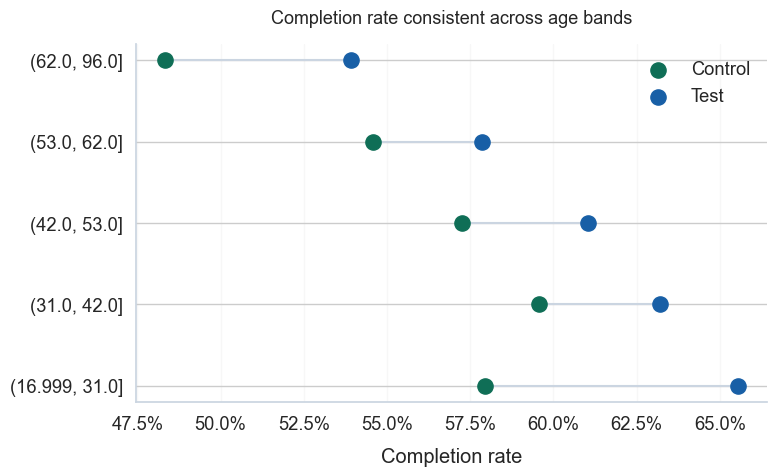

In [84]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

df_plot = df_c.copy()
df_plot['age_band'] = pd.qcut(df_plot['clnt_age'], q=5)
dot_data = df_plot.groupby(['age_band', 'group'])['completed'].mean().unstack().reset_index()
dot_data['age_band'] = dot_data['age_band'].astype(str)

fig, ax = plt.subplots(figsize=(8, 5))

palette = {"control": "#0f6e56", "test": "#185fa6"}

for _, row in dot_data.iterrows():
    # connecting line between control and test for same band
    ax.plot([row['control'], row['test']], [row['age_band'], row['age_band']],
            color='#cbd5e1', linewidth=1.5, zorder=1)

for group, color in palette.items():
    ax.scatter(dot_data[group], dot_data['age_band'],
               color=color, s=120, zorder=3, label=group.capitalize())

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Completion rate", labelpad=10)
ax.set_ylabel("")
ax.set_title("Completion rate consistent across age bands", pad=15, fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cbd5e1')
ax.spines['bottom'].set_color('#cbd5e1')
ax.grid(True, axis='x', alpha=0.15)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

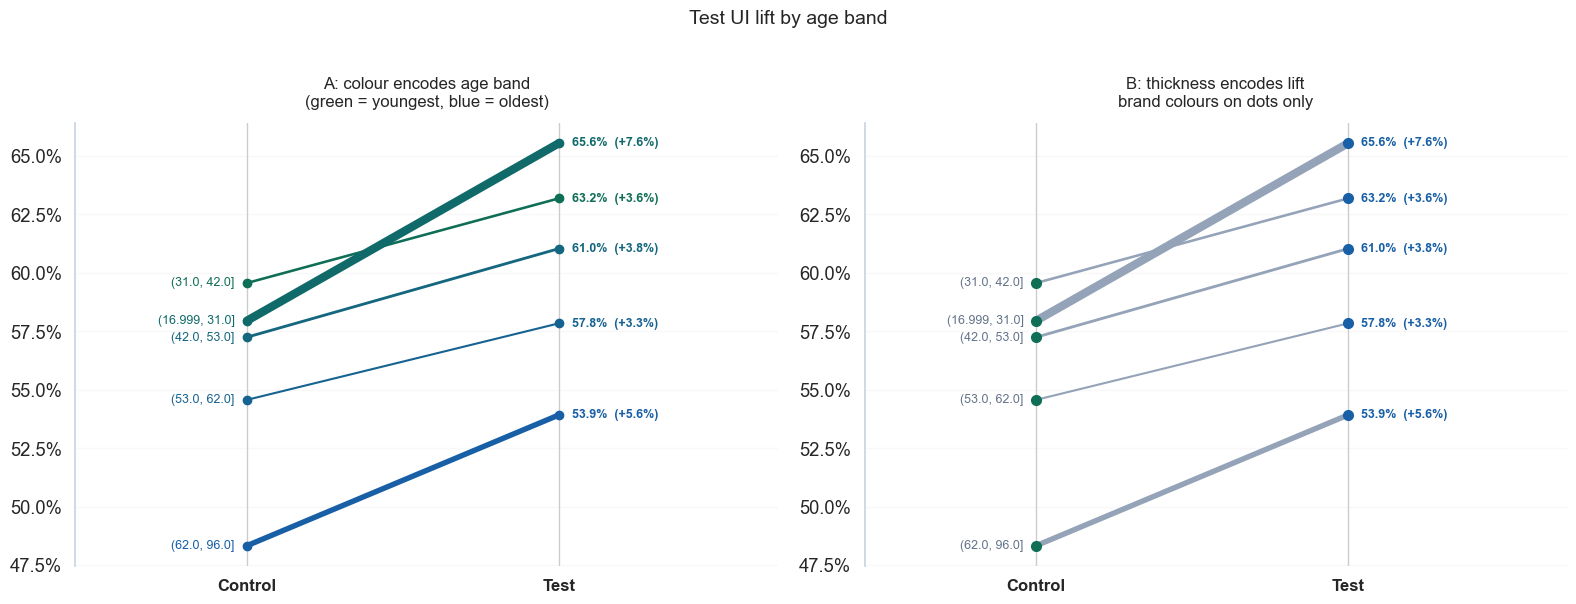

In [85]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np

df_plot = df_c.copy()
df_plot['age_band'] = pd.qcut(df_plot['clnt_age'], q=5)
slope_data = df_plot.groupby(['age_band', 'group'])['completed'].mean().unstack()
slope_data['lift'] = slope_data['test'] - slope_data['control']
slope_data = slope_data.sort_values('control', ascending=False)

lifts = slope_data['lift'].values
lw_min, lw_max = 1.5, 6
lws = lw_min + (lifts - lifts.min()) / (lifts.max() - lifts.min()) * (lw_max - lw_min)

def style_ax(ax):
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Test'], fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(-0.55, 1.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.grid(True, axis='y', alpha=0.12)

# --- Option A: green to blue gradient by age band ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

import matplotlib.colors as mcolors
green = np.array(mcolors.to_rgb('#0f6e56'))
blue  = np.array(mcolors.to_rgb('#185fa6'))
n = len(slope_data)
gradient_colors = [green + (blue - green) * i/(n-1) for i in range(n)]

ax = axes[0]
for i, (band, row) in enumerate(slope_data.iterrows()):
    ax.plot([0, 1], [row['control'], row['test']],
            color=gradient_colors[i], linewidth=lws[i],
            marker='o', markersize=6, zorder=3, solid_capstyle='round')
    ax.text(-0.04, row['control'], str(band),
            va='center', ha='right', fontsize=9, color=gradient_colors[i])
    ax.text(1.04, row['test'],
            f"{row['test']:.1%}  (+{row['lift']:.1%})",
            va='center', ha='left', fontsize=9,
            color=gradient_colors[i], fontweight='bold')

ax.set_title("A: colour encodes age band\n(green = youngest, blue = oldest)", pad=12, fontsize=12)
style_ax(ax)

# --- Option B: grey lines, thickness = lift, dots in brand colours ---
ax = axes[1]
for i, (band, row) in enumerate(slope_data.iterrows()):
    ax.plot([0, 1], [row['control'], row['test']],
            color='#94a3b8', linewidth=lws[i],
            zorder=2, solid_capstyle='round')
    ax.plot(0, row['control'], 'o', color='#0f6e56', markersize=7, zorder=3)
    ax.plot(1, row['test'],    'o', color='#185fa6', markersize=7, zorder=3)
    ax.text(-0.04, row['control'], str(band),
            va='center', ha='right', fontsize=9, color='#64748b')
    ax.text(1.04, row['test'],
            f"{row['test']:.1%}  (+{row['lift']:.1%})",
            va='center', ha='left', fontsize=9,
            color='#185fa6', fontweight='bold')

ax.set_title("B: thickness encodes lift\nbrand colours on dots only", pad=12, fontsize=12)
style_ax(ax)

plt.suptitle("Test UI lift by age band", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

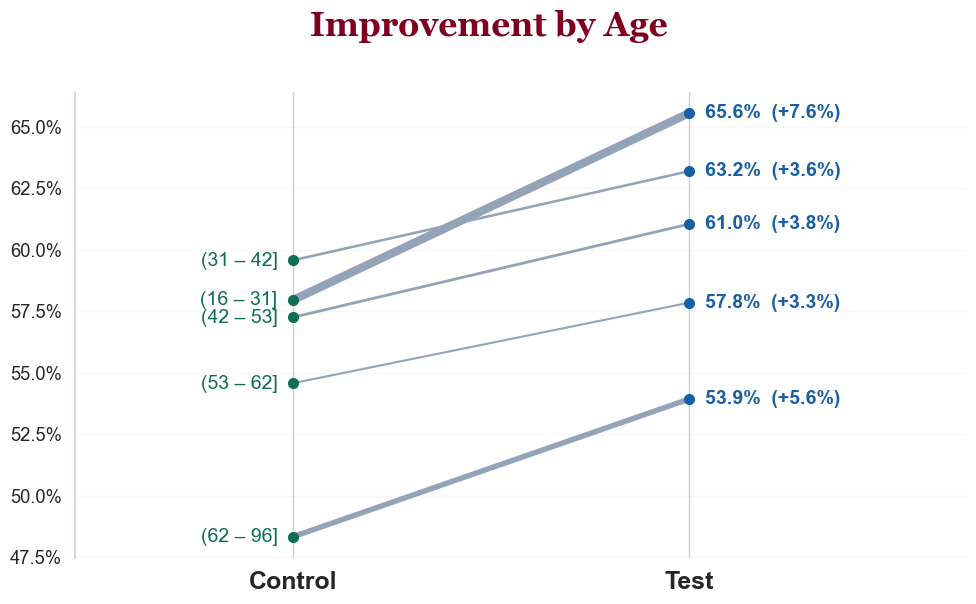

In [101]:
df_plot = df_c.copy()
# df_plot['age_band'] = pd.qcut(df_plot['clnt_age'], q=5)

df_plot['age_band'] = pd.qcut(df_plot['clnt_age'], q=5)
df_plot['age_band'] = df_plot['age_band'].cat.rename_categories(
    lambda x: f"({int(x.left)} – {int(x.right)}]"
)
slope_data = df_plot.groupby(['age_band', 'group'])['completed'].mean().unstack()
slope_data['lift'] = slope_data['test'] - slope_data['control']
slope_data = slope_data.sort_values('control', ascending=False)

lifts = slope_data['lift'].values
lw_min, lw_max = 1.5, 6
lws = lw_min + (lifts - lifts.min()) / (lifts.max() - lifts.min()) * (lw_max - lw_min)

def style_ax(ax):
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Test'], fontsize=18, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(-0.55, 1.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.grid(True, axis='y', alpha=0.12)

# --- Option A: green to blue gradient by age band ---
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# import matplotlib.colors as mcolors
# green = np.array(mcolors.to_rgb('#0f6e56'))
# blue  = np.array(mcolors.to_rgb('#185fa6'))
# n = len(slope_data)
# gradient_colors = [green + (blue - green) * i/(n-1) for i in range(n)]

# ax = axes[0]
# for i, (band, row) in enumerate(slope_data.iterrows()):
#     ax.plot([0, 1], [row['control'], row['test']],
#             color=gradient_colors[i], linewidth=lws[i],
#             marker='o', markersize=6, zorder=3, solid_capstyle='round')
#     ax.text(-0.04, row['control'], str(band),
#             va='center', ha='right', fontsize=9, color=gradient_colors[i])
#     ax.text(1.04, row['test'],
#             f"{row['test']:.1%}  (+{row['lift']:.1%})",
#             va='center', ha='left', fontsize=9,
#             color=gradient_colors[i], fontweight='bold')

# ax.set_title("A: colour encodes age band\n(green = youngest, blue = oldest)", pad=12, fontsize=12)
# style_ax(ax)

# --- Option B: grey lines, thickness = lift, dots in brand colours ---
fig, ax = plt.subplots( figsize=(10, 6))
# ax = axes[1]
for i, (band, row) in enumerate(slope_data.iterrows()):
    ax.plot([0, 1], [row['control'], row['test']],
            color='#94a3b8', linewidth=lws[i],
            zorder=2, solid_capstyle='round')
    ax.plot(0, row['control'], 'o', color='#0f6e56', markersize=7, zorder=3)
    ax.plot(1, row['test'],    'o', color='#185fa6', markersize=7, zorder=3)
    ax.text(-0.04, row['control'], str(band),
            va='center', ha='right', fontsize=14, color='#0f6e56')#'#64748b')
    ax.text(1.04, row['test'],
            f"{row['test']:.1%}  (+{row['lift']:.1%})",
            va='center', ha='left', fontsize=14,
            color='#185fa6', fontweight='bold')

# ax.set_title("B: thickness encodes lift\nbrand colours on dots only", pad=12, fontsize=12)
style_ax(ax)
gfont = {'fontname':'Georgia'}
plt.suptitle("Improvement by Age", fontsize=24, y=1.01, color='#800020',fontweight='bold',**gfont)
plt.tight_layout()
output_path = os.path.join("..", "figures", "age_bands.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)

plt.show()

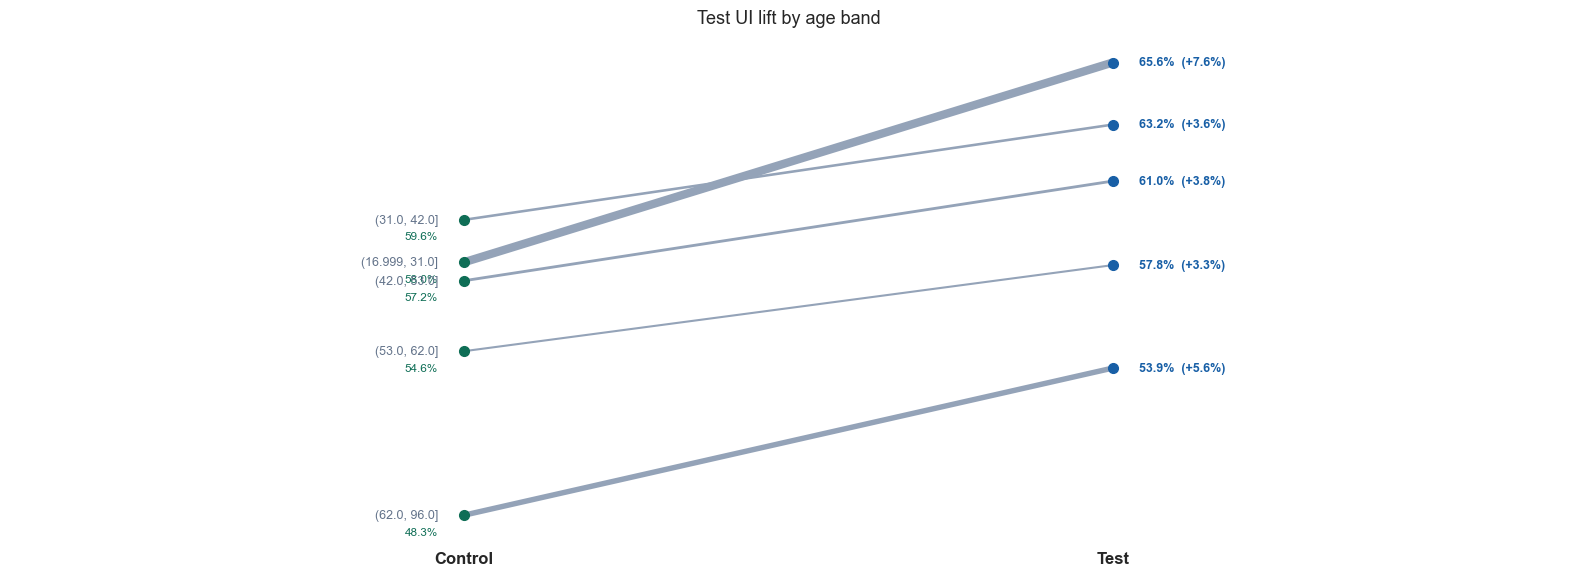

In [87]:

df_plot = df_c.copy()
df_plot['age_band'] = pd.qcut(df_plot['clnt_age'], q=5)
slope_data = df_plot.groupby(['age_band', 'group'])['completed'].mean().unstack()
slope_data['lift'] = slope_data['test'] - slope_data['control']
slope_data = slope_data.sort_values('control', ascending=False)

lifts = slope_data['lift'].values
lw_min, lw_max = 1.5, 6
lws = lw_min + (lifts - lifts.min()) / (lifts.max() - lifts.min()) * (lw_max - lw_min)

def style_ax(ax):
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Test'], fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(-0.55, 1.7)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('#cbd5e1')
    ax.grid(True, axis='y', alpha=0.12)

fig, axes = plt.subplots( figsize=(16, 6))

ax = axes
for i, (band, row) in enumerate(slope_data.iterrows()):
    ax.plot([0, 1], [row['control'], row['test']],
            color='#94a3b8', linewidth=lws[i],
            zorder=2, solid_capstyle='round')
    ax.plot(0, row['control'], 'o', color='#0f6e56', markersize=7, zorder=3)
    ax.plot(1, row['test'],    'o', color='#185fa6', markersize=7, zorder=3)
    ax.text(-0.04, row['control'], str(band),
            va='center', ha='right', fontsize=9, color='#64748b')
    ax.text(1.04, row['test'],
            f"{row['test']:.1%}  (+{row['lift']:.1%})",
            va='center', ha='left', fontsize=9,
            color='#185fa6', fontweight='bold')
    # add control rate label on left dots too
    ax.text(-0.04, row['control'], f"\n{row['control']:.1%}",
            va='top', ha='right', fontsize=8.5, color='#0f6e56')

ax.set_title("Test UI lift by age band", pad=12, fontsize=13)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Test'], fontsize=12, fontweight='bold')
ax.set_xlim(-0.7, 1.7)
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

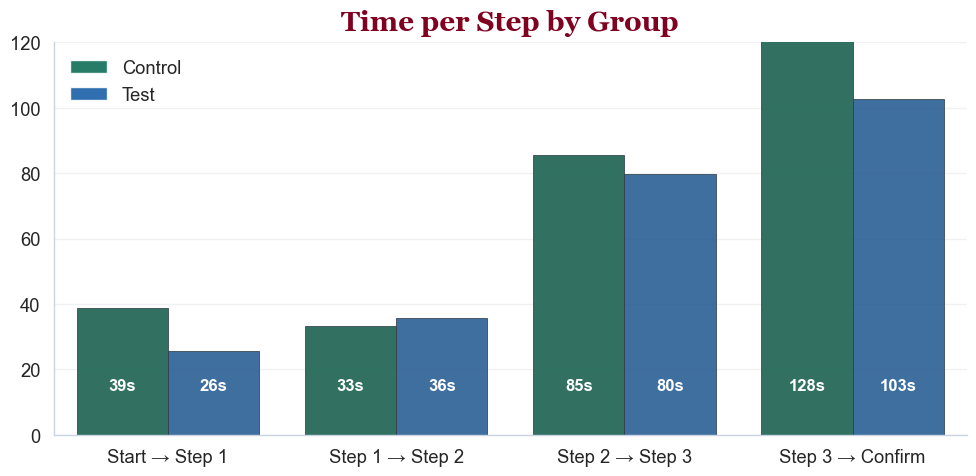

In [117]:
step_labels_t = {
    'time_start_step1': 'Start → Step 1',
    'time_step1_step2': 'Step 1 → Step 2',
    'time_step2_step3': 'Step 2 → Step 3',
    'time_step3_confirm': 'Step 3 → Confirm'
}
df_t['step_label'] = df_t['step'].map(step_labels_t)
step_order_t = list(step_labels_t.values())

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_t,
    x='step_label',
    y='time(seconds)',
    hue='condition',
    order=step_order_t,
    palette=['#0f6e56', '#185fa6'],
    ax=ax,
    edgecolor='#2f3e46',
    linewidth=0.6,
    alpha=0.9
)

ax.grid(True, axis='y', color='#94a3b8', linestyle='-', alpha=0.15)
ax.grid(False, axis='x')
ax.set_ylim(0, 120)

ax.set_xlabel('')
ax.set_ylabel('')
gfont = {'fontname': 'Georgia'}
ax.set_title('Time per Step by Group', fontsize=20, y=1.01,
             color='#800020', fontweight='bold', **gfont)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cbd5e1')
    ax.spines[spine].set_linewidth(1)

label_y = 15
colors = ['#0f6e56', '#185fa6']
# for i, p in enumerate(ax.patches):
#     height = p.get_height()
#     ax.text(
#         p.get_x() + p.get_width() / 2,
#         label_y,
#         f"{height:.0f}s",
#         ha='center', va='center',
#         fontsize=12, fontweight='bold', color='white'
#     )

for p in ax.patches:
    height = p.get_height()
    if height <= 0:
        continue
    ax.text(
        p.get_x() + p.get_width() / 2,
        label_y,
        f"{height:.0f}s",
        ha='center', va='center',
        fontsize=12, fontweight='bold', color='white'
    )

# replace legend with patches
legend_elements = [
    mpatches.Patch(facecolor='#0f6e56', alpha=0.9, label='Control'),
    mpatches.Patch(facecolor='#185fa6', alpha=0.9, label='Test'),
]
ax.legend(handles=legend_elements, frameon=False)
# ax.legend(title='', labels=['Control', 'Test'], frameon=False)

plt.tight_layout()
output_path = os.path.join('..', 'figures', 'time_per_step.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [122]:
sum(df_t[df_t.condition=='test']['time(seconds)'])

243.66000000000003

In [123]:
sum(df_t[df_t.condition=='control']['time(seconds)'])

285.24

In [127]:
df_c.completion_seconds.mean()

np.float64(284.9736523534857)